In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import muspan as ms
from itertools import zip_longest
from typing import List, Tuple, Optional
import math
from functools import partial
import seaborn as sns
from scipy import stats
import pathlib

In [ ]:
met_nos = [2,2,1,1,3,17,4,23,7,13]
domains_order = ['AKPT_Liver_Mets_4d_1_Region_1', 
           'AKPT_Liver_Mets_4d_1_Region_2', 
           'AKPT_Liver_Mets_4d_2_Region_1', 
           'AKPT_Liver_Mets_4d_3_Region_1', 
           'AKPT_Liver_Mets_4d_5_Region_1', 
           'AKPT_Liver_Mets_28d_1_Region_1',
           'AKPT_Liver_Mets_28d_1_Region_2',
           'AKPT_Liver_Mets_28d_2_Region_1',
           'AKPT_Liver_Mets_28d_2_Region_2',
           'AKPT_Liver_Mets_28d_3_Region_1']

In [3]:
## Change to location of AKPT_Liver_Mets folder
# directory = pathlib.Path("../domains_with_mets")
directory = pathlib.Path("../outputs/In_out")

In [16]:
i=0
list_of_files = []
for item in directory.rglob("*"):
    if item.is_file():
            if str(item) != str(directory)+'/.DS_Store':
                list_of_files.append(str(item))
            i+=1

In [5]:
names = [x.replace('../domains_with_mets/', '').replace('.muspan', '') for x in list_of_files]

In [17]:
print(list_of_files)

['../outputs/In_out/Sample_4d_5.muspan', '../outputs/In_out/Sample_4d_1_2.muspan', '../outputs/In_out/Sample_28d_2_2.muspan', '../outputs/In_out/Sample_4d_3.muspan', '../outputs/In_out/Sample_28d_2.muspan', '../outputs/In_out/Sample_4d_1.muspan', '../outputs/In_out/Sample_28d_1.muspan', '../outputs/In_out/Sample_4d_2.muspan', '../outputs/In_out/Sample_28d_3.muspan', '../outputs/In_out/Sample_28d_1_2.muspan']


In [19]:
list_of_domains = []
for i in range(len(list_of_files)):
# for i in range(4,5):
    list_of_domains.append(ms.io.load_domain(list_of_files[i]))

MuSpAn domain loaded successfully. Domain summary:
Domain name: AKPT_Liver_Mets_4d_5_Region_1
Number of objects: 83958
Collections: ['Cell boundaries', 'Met annotations', 'Cell centres', 'Detailed Met Annotations', 'Cell Boundaries in Met 1', 'Cell Centres in Met 1', 'Metastasis 1', 'Cell Boundaries in Met 2', 'Cell Centres in Met 2', 'Metastasis 2', 'Cell Boundaries in Met 3', 'Cell Centres in Met 3', 'Metastasis 3']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Cluster ID', 'Nucleus Area', 'Transcript Counts: 1700019D03Rik', 'Transcript Counts: Abcc8', 'Transcript Counts: Acta2', 'Transcript Counts: Acvr1b', 'Transcript Counts: Acvr2a', 'Transcript Counts: Adgra2', 'Transcript Counts: Adgre1', 'Transcript Counts: Adh1', 'Transcript Counts: Adra2a', 'Transcript Counts: Afap1l2', 'Transcript Counts: Alb', 'Transcript Counts: Alcam', 'Transcript Counts: Aldh1b1', 'Transcript Counts: Aldoa', 'Transcript Counts: Amotl2', 'Transcript Counts: Ano7', 'Transcript Counts: Anxa1', 'Tra

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

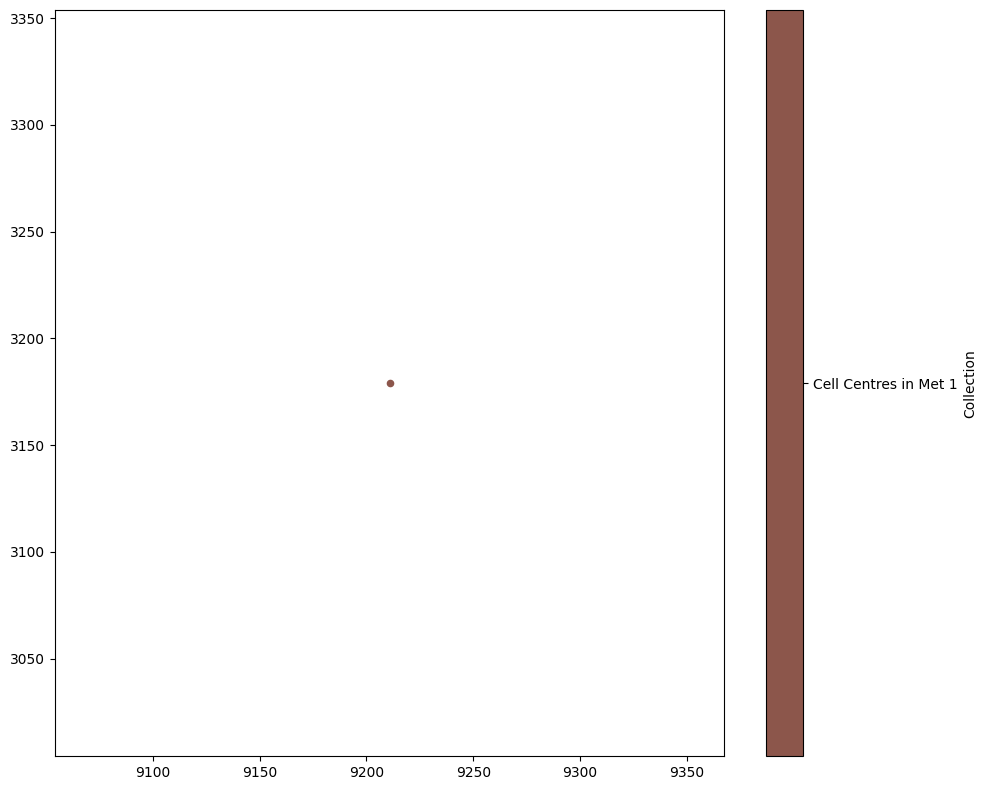

In [15]:
ms.visualise.visualise(list_of_domains[0], objects_to_plot=('collection', 'Cell Centres in Met 1'))

In [ ]:
query_kupffer = ms.query.query(list_of_domains[2], ('label', 'Detailed celltype (liver)'), 'is', 'Kupffer cells')
query_in_met = ms.query.query(list_of_domains[2], ('contains', (query_kupffer, ('collection', 'Tumour_Met_New'))), 'is', True)
ms.visualise.visualise(list_of_domains[2], objects_to_plot=query_in_met)

In [43]:
domain.labels['Cell ID']['labels']


array(['bjieojol-1', 'jnjlinjj-1', 'oganmklh-1', ..., 'hdchedpk-1',
       'ahibmcih-1', 'beedcncn-1'], dtype='<U10')

In [53]:
index = np.where(domain.labels['Cell ID']['objects'] == i)[0][0]
domain.labels['Cell ID']['labels'][index]


np.str_('bjieojol-1')

In [90]:
print(list_of_domains[0].name)
print(domains_order.index(str(list_of_domains[0].name)))

AKPT_Liver_Mets_4d_2_Region_1
2


In [20]:
## far more efficient method thanks to Padraig
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    query_contained = ms.query.query(domain,('collection',), 'is', 'Cell Centres in Met 1')
    for region_no in range(met_no):
        shape_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is', 'Metastasis '+str(region_no+1)))
        shape_cells = ms.query.return_object_IDs_from_query_like(domain,('collection', 'Cell Centres in Met '+str(region_no+1)),bypass_checks=True)
        query_contained_temp = ms.query.query(domain,('collection',), 'is', 'Cell Centres in Met '+str(region_no+1))
        query_contained = ms.query.query_container(query_contained_temp, 'OR', query_contained, domain)
        distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=shape_cells, population_B=shape_ID)
        shape_cell_distances = np.stack([shape_cells,distances.min(axis=1)])
    
        np.save('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1), shape_cell_distances, allow_pickle=True)
    
    shapes_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is', 'Detailed Met Annotations'))
    query_centre = ms.query.query(domain, ('collection', ), 'is', 'Cell centres')
    query_not_contained = ms.query.query_container(query_centre, 'AND NOT', query_contained)
    outside_cells = ms.query.return_object_IDs_from_query_like(domain,query_not_contained,bypass_checks=True)
    for region_no in range(met_no):
        shape_ID = ms.query.query(domain, ('collection',),  'is', 'Metastasis '+str(region_no+1))
    
        distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=outside_cells, population_B=shape_ID)
        outside_met_cell_distances = np.stack([outside_cells,distances.min(axis=1)])
    
        np.save('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_Met_'+str(region_no+1), outside_met_cell_distances, allow_pickle=True)
    
    shapes = ms.query.query(domain, ('collection',),  'is', 'Detailed Met Annotations')
    distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=outside_cells, population_B=shapes)
    outside_met_cell_distances = np.stack([outside_cells,distances.min(axis=1)])

    np.save('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets', outside_met_cell_distances, allow_pickle=True)


In [28]:
print(outside_met_cell_distances)

[[234189.         234191.         234197.         ... 468366.
  468367.         468368.        ]
 [  5669.5438484    6472.09902185   6401.85676146 ...   2332.3033143
    2347.33762294   2341.25884374]]


In [102]:
## far more efficient method thanks to Padraig
for dom in range(4, len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    query_not_contained = ms.query.query(domain, ('collection', ), 'is', 'Cell centres')
    for region_no in range(met_no):
        shape_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is', 'Metastasis '+str(region_no+1)))
        shape_cells = ms.query.return_object_IDs_from_query_like(domain,('collection', 'Cell Centres in Met '+str(region_no+1)),bypass_checks=True)
        query_not_contained_temp = ms.query.query(domain,('collection',), 'is not', 'Cell Centres in Met '+str(region_no+1))
        query_not_contained = ms.query.query_container(query_not_contained_temp, 'AND', query_not_contained, domain)
        distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=shape_cells, population_B=shape_ID)
        shape_cell_distances = np.stack([shape_cells,distances.min(axis=1)])
    
        np.save('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1), shape_cell_distances, allow_pickle=True)
    
    # shapes_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is', 'Detailed Met Annotations'))
    outside_cells = ms.query.return_object_IDs_from_query_like(domain,query_not_contained,bypass_checks=True)
    for region_no in range(met_no):
        shape_ID = ms.query.query(domain, ('collection',),  'is', 'Metastasis '+str(region_no+1))
    
        distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=outside_cells, population_B=shape_ID)
        outside_met_cell_distances = np.stack([outside_cells,distances.min(axis=1)])
    
        np.save('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_Met_'+str(region_no+1), outside_met_cell_distances, allow_pickle=True)


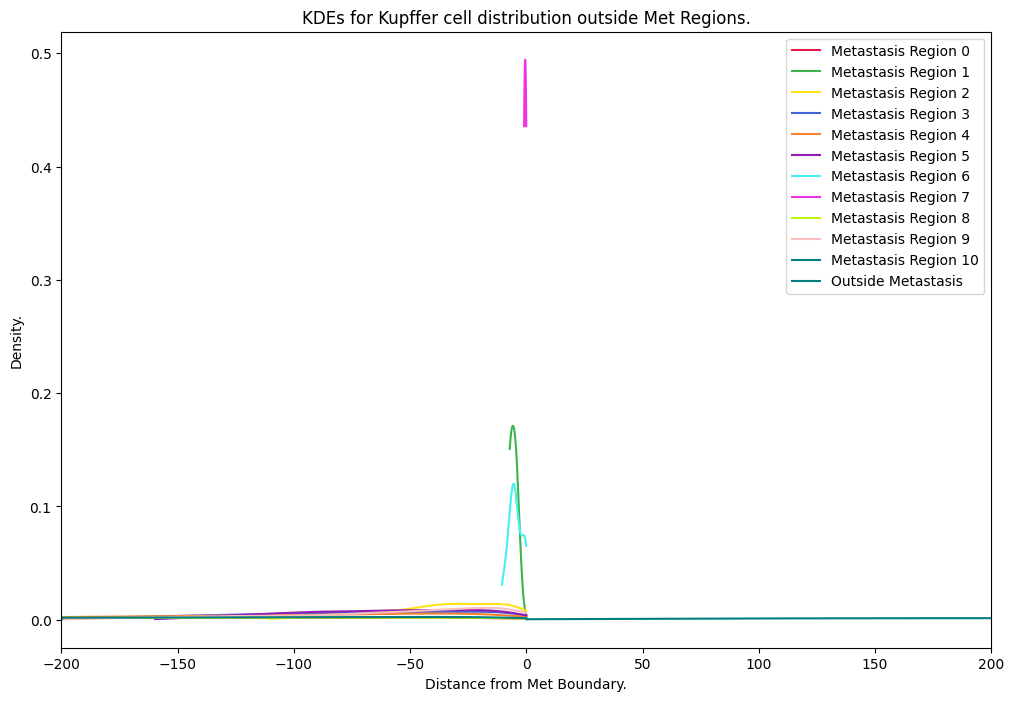

In [ ]:
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(list_of_domains[dom].name))]
    for region_no in range(met_no):
        shapes_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is', 'Metastasis '+str(region_no)))
        all_densities = []
        query_kupffer = ms.query.query(domain, ('label', 'Detailed celltype (liver)'), 'is', 'Kupffer cells')
        colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
        query_not_contained = ms.query.query(domain, ('label', 'Detailed celltype (liver)'), 'is', 'Kupffer cells')
        fig, axes = plt.subplots(1, 1, figsize=(12, 8))
        axes.set_title('KDEs for Kupffer cell distribution outside Met Regions.')
        axes.set_xlabel('Distance from Met Boundary.')
        axes.set_ylabel('Density.')
        # loop through each subshape
        for shapes_counter in range(len(shapes_ID)):
            shape_ID = shapes_ID[shapes_counter]
            cell_IDs = ms.query.return_object_IDs_from_query_like(domain, query_kupffer, bypass_checks=True)

            query_contained = ms.query.query(domain,('contains',(query_kupffer,  [shape_ID])), 'is', True)
            query_not_contained_temp = ms.query.query(domain,('contains',(query_kupffer,  [shape_ID])), 'is', False)
            query_not_contained = ms.query.query_container(query_not_contained_temp, 'AND', query_not_contained, domain)

            domain.add_objects_to_collection(query_contained, collection_name = 'Met_'+str(shapes_counter)+'_cells')

            ### Calculate distance to boundary from these points
            met_cells = ms.query.return_object_IDs_from_query_like(domain, ('collection', 'Met_'+str(shapes_counter)+'_cells'),bypass_checks=True) 

            if len(met_cells) > 0:
                distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=met_cells, population_B=[shape_ID])
                inside_met_cell_distances = np.stack([met_cells,distances.min(axis=1)])

                if len(inside_met_cell_distances[1])>1:
                    x_max = np.max(inside_met_cell_distances[1])
                    kde = stats.gaussian_kde(inside_met_cell_distances[1])
                    x_eval = np.linspace(0, x_max, num=200)
                    array_temp = np.array(x_eval)*-1
                    x = list(array_temp)
                    axes.plot(x, kde(x_eval), color = colours[shapes_counter],label='Metastasis Region ' +str(shapes_counter))



        met_cells = ms.query.return_object_IDs_from_query_like(domain, query_not_contained,bypass_checks=True) 

        distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=met_cells, population_B=shapes_ID)
        outside_met_cell_distances = np.stack([met_cells,distances.min(axis=1)])

        x_max = np.max(outside_met_cell_distances[1])
        kde = stats.gaussian_kde(outside_met_cell_distances[1])
        x_eval = np.linspace(0, x_max, num=200)
        axes.plot(x_eval, kde(x_eval), color = colours[shapes_counter],label='Outside Metastasis')

    axes.set_xlim([-200, 200])
    leg = axes.legend()


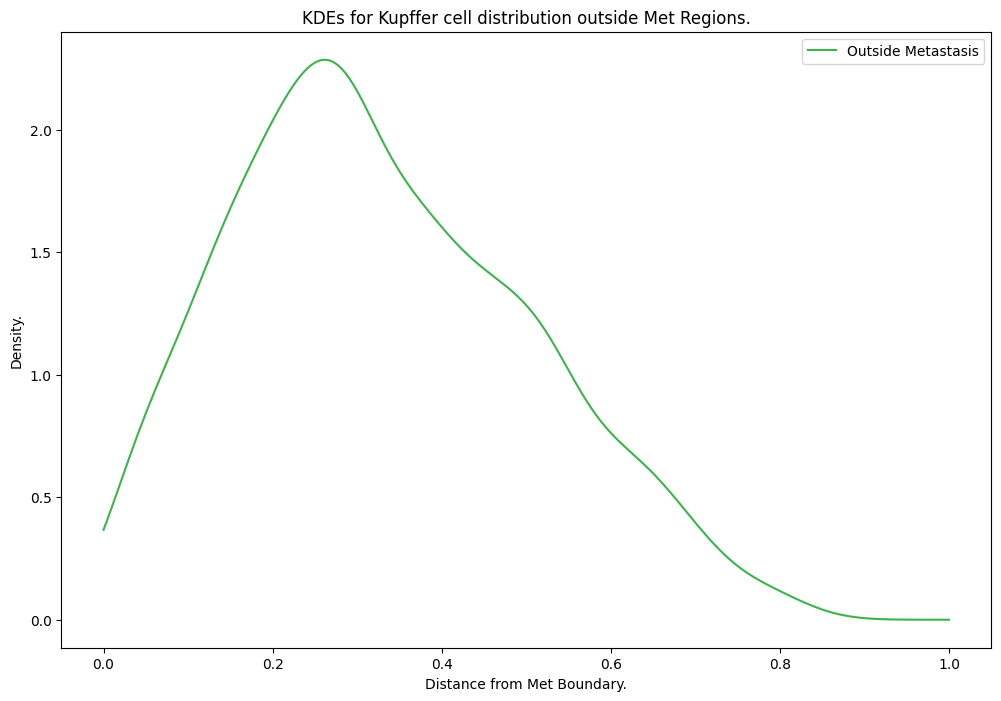

In [67]:
domain = list_of_domains[2]
shapes_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is', 'Tumour_Met_New'))
all_densities = []
query_kupffer = ms.query.query(domain, ('label', 'Detailed celltype (liver)'), 'is', 'Kupffer cells')
query_cell = ms.query.query(domain, ('collection',), 'is', 'Cell boundaries')
colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
query_not_contained = ms.query.query(domain, ('label', 'Detailed celltype (liver)'), 'is', 'Kupffer cells')
fig, axes = plt.subplots(1, 1, figsize=(12, 8))
axes.set_title('KDEs for Kupffer cell distribution outside Met Regions.')
axes.set_xlabel('Distance from Met Boundary.')
axes.set_ylabel('Density.')
# loop through each subshape
for shapes_counter in range(len(shapes_ID)):
    shape_ID = shapes_ID[shapes_counter]
    cell_IDs = ms.query.return_object_IDs_from_query_like(domain, query_kupffer, bypass_checks=True)

    query_contained = ms.query.query(domain,('contains',(query_cell,  [shape_ID])), 'is', True)
    query_not_contained_temp = ms.query.query(domain,('contains',(query_cell,  [shape_ID])), 'is', False)
    query_not_contained = ms.query.query_container(query_not_contained_temp, 'AND', query_not_contained, domain)

    domain.add_objects_to_collection(query_contained, collection_name = 'Met_'+str(shapes_counter)+'_cells')

    ### Calculate distance to boundary from these points
    met_cells = ms.query.return_object_IDs_from_query_like(domain, ('collection', 'Met_'+str(shapes_counter)+'_cells'),bypass_checks=True) 
    kupffer_met_cells = ms.query.query_container(query_contained, 'AND', query_kupffer, domain) 
    kupffer_met_cells_list = ms.query.return_object_IDs_from_query_like(domain, kupffer_met_cells)

    # shape_cells_counter = ms.query.return_object_IDs_from_query_like(domain, ('collection', str(shape)+str(shapes_counter)+'_cells'),  bypass_checks=True)
    # medulla_shapes = ms.query.query(domain, ('collection',),  'is', 'simplified_Med'+str(shapes_counter))
    if len(met_cells) >0:
        distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=met_cells, population_B=[shape_ID])
        inside_met_cell_distances = np.stack([met_cells,distances.min(axis=1)])

        distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=kupffer_met_cells, population_B=[shape_ID])
        kupffer_inside_met_cell_distances = np.stack([kupffer_met_cells_list,distances.min(axis=1)])

        normalised_distances = kupffer_inside_met_cell_distances[1]/np.max(inside_met_cell_distances[1])
        if len(normalised_distances)>1:
            kde = stats.gaussian_kde(normalised_distances)
            x_eval = np.linspace(0, 1, num=200)
            array_temp = np.array(x_eval)*-1
            x = list(array_temp)
            axes.plot(x, kde(x_eval), color = colours[shapes_counter],label='Metastasis Region ' +str(shapes_counter))



met_cells = ms.query.return_object_IDs_from_query_like(domain, query_not_contained,bypass_checks=True) 
kupffer_met_cells = ms.query.query_container(query_not_contained, 'AND', query_kupffer, domain) 
kupffer_met_cells_list = ms.query.return_object_IDs_from_query_like(domain, kupffer_met_cells)

distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=met_cells, population_B=shapes_ID)
outside_met_cell_distances = np.stack([met_cells,distances.min(axis=1)])

distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=kupffer_met_cells, population_B=[shape_ID])
kupffer_outside_met_cell_distances = np.stack([kupffer_met_cells_list,distances.min(axis=1)])

normalised_distances = outside_met_cell_distances[1]/np.max(kupffer_outside_met_cell_distances[1])
kde = stats.gaussian_kde(normalised_distances)
x_eval = np.linspace(0, 1, num=200)
axes.plot(x_eval, kde(x_eval), color = colours[shapes_counter],label='Outside Metastasis')

leg = axes.legend()


In [35]:
print(outside_met_cell_distances[1])

[2.03554215e+01 9.25299299e-01 1.26829474e+01 ... 1.94038228e+03
 2.06275903e+03 2.00734690e+03]


In [36]:
normalised_distances = outside_met_cell_distances[1]/np.max(outside_met_cell_distances[1])

In [37]:
kde = stats.gaussian_kde(outside_met_cell_distances[1])

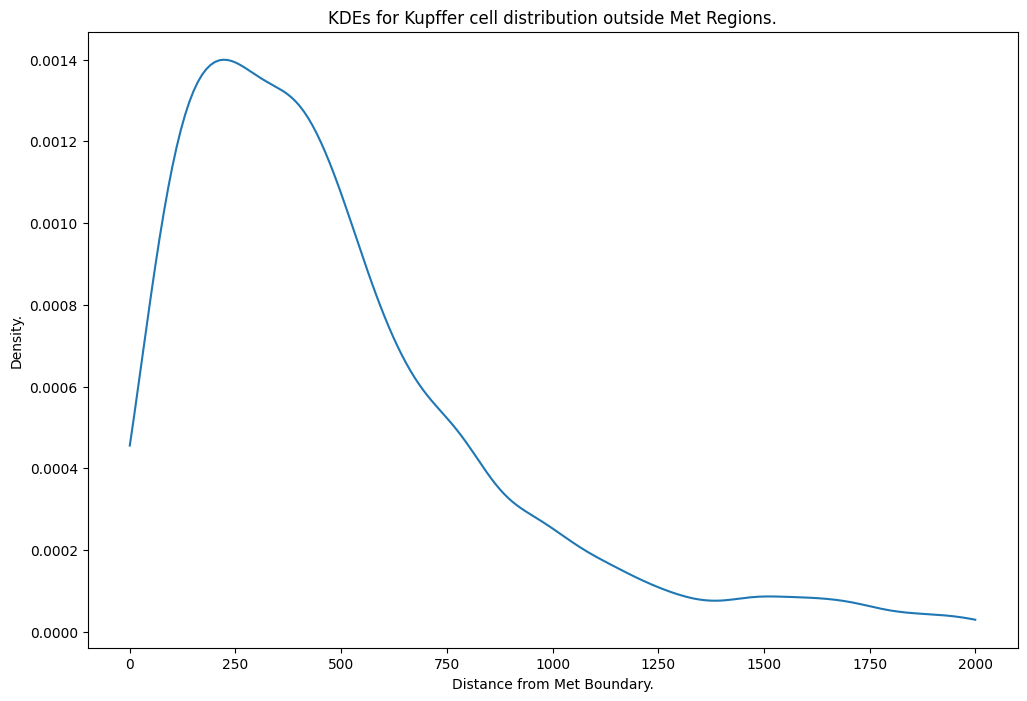

In [38]:
x_eval = np.linspace(0, 2000, num=200)
fig, axes = plt.subplots(1, 1, figsize=(12, 8))
axes.set_title('KDEs for Kupffer cell distribution outside Met Regions.')
axes.set_xlabel('Distance from Met Boundary.')
axes.set_ylabel('Density.')
axes.plot(x_eval, kde(x_eval))